In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from imblearn.over_sampling import SMOTE
from sklearn.metrics import f1_score, classification_report

In [2]:
df = pd.read_csv("cancer_risk_dataset.csv")
df.head(4)

,Patient_ID,Cancer_Type,Age,Gender,Smoking,Alcohol_Use,Obesity,Family_History,Diet_Red_Meat,Diet_Salted_Processed,...,Physical_Activity,Air_Pollution,Occupational_Hazards,BRCA_Mutation,H_Pylori_Infection,Calcium_Intake,Overall_Risk_Score,BMI,Physical_Activity_Level,Risk_Level
0,LU0000,Breast,68,0,7,2,8,0,5,3,...,4,6,3,1,0,0,0.398696,28.0,5,Medium
1,LU0001,Prostate,74,1,8,9,8,0,0,3,...,1,3,3,0,0,5,0.424299,25.4,9,Medium
2,LU0002,Skin,55,1,7,10,7,0,3,3,...,1,8,10,0,0,6,0.605082,28.6,2,Medium
3,LU0003,Colon,61,0,6,2,2,0,6,2,...,6,4,8,0,0,8,0.318449,32.1,7,Low


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Patient_ID               2000 non-null   object 
 1   Cancer_Type              2000 non-null   object 
 2   Age                      2000 non-null   int64  
 3   Gender                   2000 non-null   int64  
 4   Smoking                  2000 non-null   int64  
 5   Alcohol_Use              2000 non-null   int64  
 6   Obesity                  2000 non-null   int64  
 7   Family_History           2000 non-null   int64  
 8   Diet_Red_Meat            2000 non-null   int64  
 9   Diet_Salted_Processed    2000 non-null   int64  
 10  Fruit_Veg_Intake         2000 non-null   int64  
 11  Physical_Activity        2000 non-null   int64  
 12  Air_Pollution            2000 non-null   int64  
 13  Occupational_Hazards     2000 non-null   int64  
 14  BRCA_Mutation           

# Existe desbalance de clases

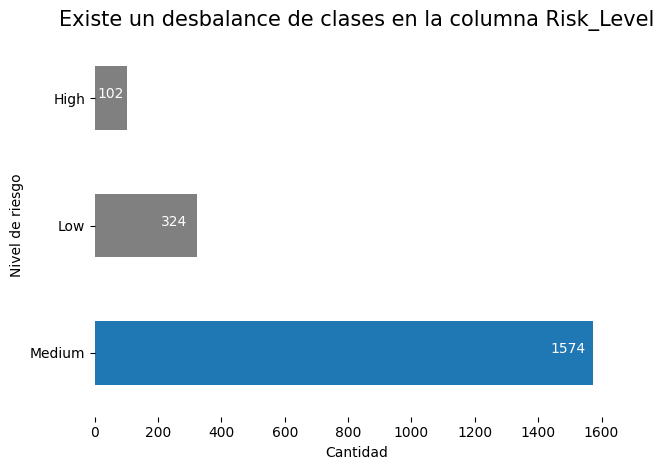

In [41]:
colors = ["tab:blue", "gray", "gray"]
df.Risk_Level.value_counts().plot.barh(color= colors)
plt.title("Existe un desbalance de clases en la columna Risk_Level", fontsize=15)


for i, val in enumerate(df.Risk_Level.value_counts().values) : 
    plt.text(val - 95 - (2 - i) * 20, i, val, color="white")

plt.ylabel("Nivel de riesgo")
plt.xlabel("Cantidad")
plt.tight_layout()
plt.gca().set_frame_on(False)

Durante el entrenamiento del modelo crearemos data para las clases minoría con SMOTE

# Mapa de correlación

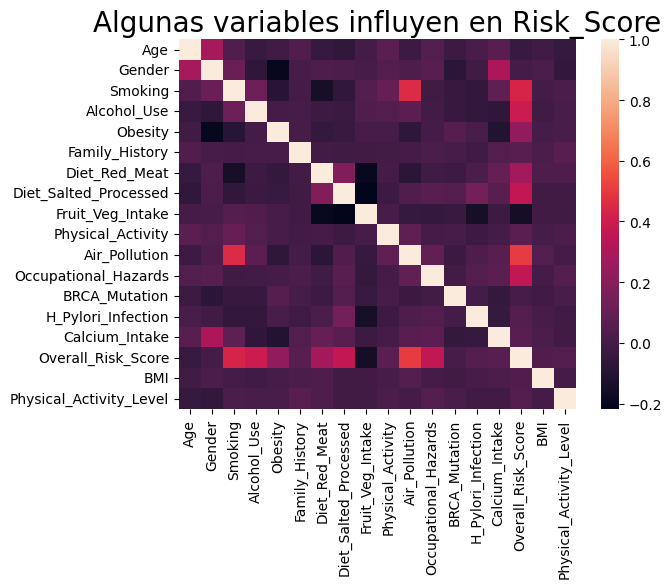

In [7]:
sns.heatmap(df.select_dtypes(["int64", "float64"]).corr())
plt.title("Algunas variables influyen en Risk_Score", fontsize=20)
plt.show()

In [10]:
df.select_dtypes(["int64", "float64"]).describe()

,Age,Gender,Smoking,Alcohol_Use,Obesity,Family_History,Diet_Red_Meat,Diet_Salted_Processed,Fruit_Veg_Intake,Physical_Activity,Air_Pollution,Occupational_Hazards,BRCA_Mutation,H_Pylori_Infection,Calcium_Intake,Overall_Risk_Score,BMI,Physical_Activity_Level
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.00000,2000.000000,2000.000000,2000.000000
mean,63.248000,0.489000,5.157000,5.035000,5.967500,0.194500,5.189500,4.563500,4.927500,4.015000,5.323000,4.979000,0.032500,0.19650,3.94050,0.454449,26.183350,4.938500
std,10.462946,0.500004,3.325339,3.260996,3.061393,0.395914,3.154452,3.088323,3.045305,2.978458,3.207462,3.212899,0.177368,0.39745,3.04887,0.123074,3.947459,3.166027
min,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.00000,0.029285,15.000000,0.000000
25%,56.000000,0.000000,2.000000,2.000000,4.000000,0.000000,3.000000,2.000000,3.000000,1.000000,3.000000,2.000000,0.000000,0.00000,1.00000,0.366982,23.500000,2.000000
50%,64.000000,0.000000,5.000000,5.000000,6.000000,0.000000,5.000000,4.000000,5.000000,4.000000,5.000000,5.000000,0.000000,0.00000,4.00000,0.455399,26.200000,5.000000
75%,70.000000,1.000000,8.000000,8.000000,9.000000,0.000000,8.000000,7.000000,8.000000,6.000000,8.000000,8.000000,0.000000,0.00000,6.00000,0.539782,28.700000,8.000000
max,90.000000,1.000000,10.000000,10.000000,10.000000,1.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,1.000000,1.00000,10.00000,0.852158,41.400000,10.000000


<Axes: >

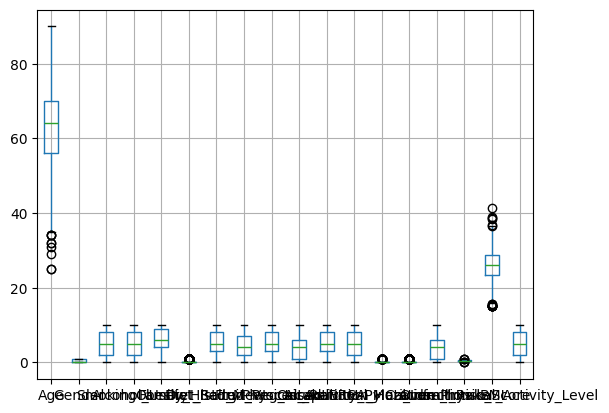

In [9]:
df.select_dtypes(["int64", "float64"]).boxplot()

# Entrenamiento del modelo

In [115]:
X = df[["Air_Pollution", "Smoking", "Alcohol_Use", "Occupational_Hazards", "Diet_Salted_Processed", "Obesity", "Diet_Red_Meat"]]
Y = df.Risk_Level

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [116]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)

In [39]:
rf.fit(X_train, Y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


# Evaluación del modelo

Evaluación del modelo en general

In [40]:
pred = rf.predict(X_test)
print(accuracy_score(Y_test, pred))

0.86


Existe desbalance de clases, evaluemos qué tan bien predice el modelo a la clase de riesgo High

Idea: Solo tomaremos los valores de X_test cuyo risk sea "High", y luego los pasaremos a predecir para ver los resultados

In [41]:
high = df[df["Risk_Level"] == "High"]


In [42]:
indexes = X_test.index.values
dropped = []
for i in high.index.values:
    if(i not in indexes):
        dropped.append(i)

X_test_high = high.drop(dropped)
X_test_high = X_test_high[["Air_Pollution", "Smoking", "Alcohol_Use", "Occupational_Hazards", "Diet_Salted_Processed", "Obesity", "Diet_Red_Meat"]]


In [144]:
print(classification_report(Y_test, pred))

              precision    recall  f1-score   support

        High       0.33      0.06      0.11        16
         Low       0.70      0.54      0.61        57
      Medium       0.88      0.95      0.92       327

    accuracy                           0.86       400
   macro avg       0.64      0.52      0.55       400
weighted avg       0.84      0.86      0.84       400



In [43]:

pred2 = rf.predict(X_test_high)
print(accuracy_score(high["Risk_Level"].drop(dropped), pred2))

0.0625


La predicción es muy mala, predice a la mayoría como "Medium"

# Entrenamiento de Random Forest con pesos (class weights)

In [4]:
weights = {'High':.9, 'Low':.5, 'Medium':.1}

In [5]:
X = df[["Air_Pollution", "Smoking", "Alcohol_Use", "Occupational_Hazards", "Diet_Salted_Processed", "Obesity", "Diet_Red_Meat"]]
Y = df.Risk_Level

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [6]:
rf_weight = RandomForestClassifier(n_estimators=200, random_state=42, class_weight=weights)

In [8]:
rf_weight.fit(X_train, Y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [149]:
pred_w = rf_weight.predict(X_test)
print(accuracy_score(Y_test, pred_w))

0.855


In [150]:
print(classification_report(Y_test, pred_w))

              precision    recall  f1-score   support

        High       0.57      0.25      0.35        16
         Low       0.68      0.47      0.56        57
      Medium       0.88      0.95      0.91       327

    accuracy                           0.85       400
   macro avg       0.71      0.56      0.61       400
weighted avg       0.84      0.85      0.84       400



In [151]:
print(f1_score(Y_test, pred_w, average="macro"))

0.6064110000790993


# Entrenando modelo con BalancedBaggingClassifier

In [9]:
from imblearn.ensemble import BalancedBaggingClassifier

In [10]:
X = df[["Air_Pollution", "Smoking", "Alcohol_Use", "Occupational_Hazards", "Diet_Salted_Processed", "Obesity", "Diet_Red_Meat"]]
Y = df.Risk_Level

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [14]:
rf_bag = RandomForestClassifier(n_estimators=200, random_state=42)

In [15]:
balanced_bagging = BalancedBaggingClassifier(
    estimator=rf_bag,
    sampling_strategy='auto',
    replacement=False,
    random_state=42
)

In [16]:
balanced_bagging.fit(X_train, Y_train)
pred_b = balanced_bagging.predict(X_test)

In [17]:
print(classification_report(Y_test, pred_b))

              precision    recall  f1-score   support

        High       0.26      0.62      0.36        16
         Low       0.47      0.96      0.64        57
      Medium       0.97      0.72      0.83       327

    accuracy                           0.76       400
   macro avg       0.57      0.77      0.61       400
weighted avg       0.87      0.76      0.78       400



# Entrenamiento (creando data con SMOTE)

In [18]:
X = df[["Air_Pollution", "Smoking", "Alcohol_Use", "Occupational_Hazards", "Diet_Salted_Processed", "Obesity", "Diet_Red_Meat"]]
Y = df.Risk_Level

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

smote = SMOTE(sampling_strategy='minority', random_state=42)
X_train_high, Y_train_high = smote.fit_resample(X_train, Y_train)
X_train_sm, Y_train_sm = smote.fit_resample(X_train_high, Y_train_high)


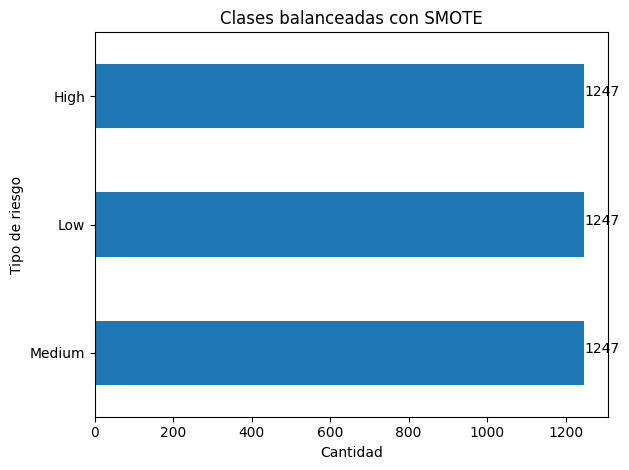

In [19]:
Y_train_sm.value_counts().plot.barh()

plt.title("Clases balanceadas con SMOTE")

for i, val in enumerate(Y_train_sm.value_counts().values) : 
    plt.text(val, i, val)
plt.ylabel("Tipo de riesgo")
plt.xlabel("Cantidad")
plt.tight_layout()

In [20]:
rf_balanced = RandomForestClassifier(n_estimators=200, random_state=42)

In [21]:
rf_balanced.fit(X_train_sm, Y_train_sm)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [23]:
pred_bal = rf_balanced.predict(X_test)

Sigue prediciendo mal la clase High (pero no tan mal como antes)

In [25]:
print(classification_report(Y_test, pred_bal))

              precision    recall  f1-score   support

        High       0.30      0.38      0.33        16
         Low       0.57      0.61      0.59        57
      Medium       0.90      0.88      0.89       327

    accuracy                           0.82       400
   macro avg       0.59      0.62      0.61       400
weighted avg       0.83      0.82      0.82       400



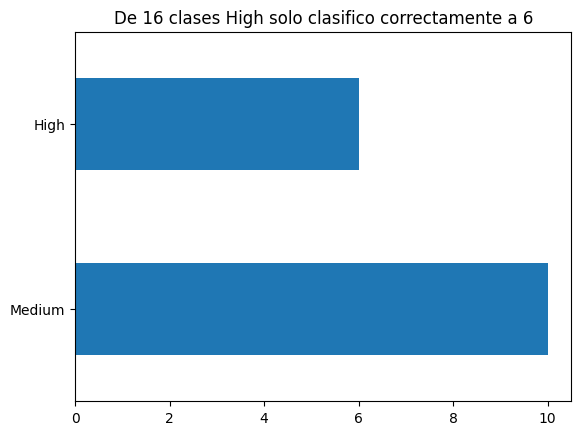

In [83]:
pd.Series(pred2).value_counts().plot.barh()
plt.title("De 16 clases High solo clasifico correctamente a 6")
plt.show()

# Entrenamiento (SMOTE + pesos en RandomForest)

In [60]:
weights = {'High':10, 'Low':.5, 'Medium':.1}

In [61]:
X = df[["Air_Pollution", "Smoking", "Alcohol_Use", "Occupational_Hazards", "Diet_Salted_Processed", "Obesity", "Diet_Red_Meat"]]
Y = df.Risk_Level

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

smote = SMOTE(sampling_strategy='minority', random_state=42)
X_train_high, Y_train_high = smote.fit_resample(X_train, Y_train)
X_train_sm, Y_train_sm = smote.fit_resample(X_train_high, Y_train_high)

In [62]:
rf_weight_SM = RandomForestClassifier(n_estimators=200, random_state=42, class_weight=weights)

In [63]:
rf_weight_SM.fit(X_train_sm, Y_train_sm)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [64]:
pred_sm = rf_weight_SM.predict(X_test)

In [65]:
d = pd.DataFrame(columns=["real","pred"])
d["real"] = Y_test
d["pred"] = pred_sm
d[d["real"] == "High"]

,real,pred
65,High,High
1179,High,High
368,High,Medium
237,High,Medium
1134,High,Medium
1813,High,High
220,High,Medium
1784,High,High
888,High,High
1966,High,Medium


In [66]:
print(classification_report(Y_test, pred_sm))

              precision    recall  f1-score   support

        High       0.29      0.38      0.32        16
         Low       0.56      0.60      0.58        57
      Medium       0.90      0.87      0.88       327

    accuracy                           0.81       400
   macro avg       0.58      0.61      0.59       400
weighted avg       0.82      0.81      0.82       400



# Columnas con mayor influencia al predecir la clase

<Axes: title={'center': 'Columnas con mayor influencia durante entrenamiento del modelo Random Forest'}>

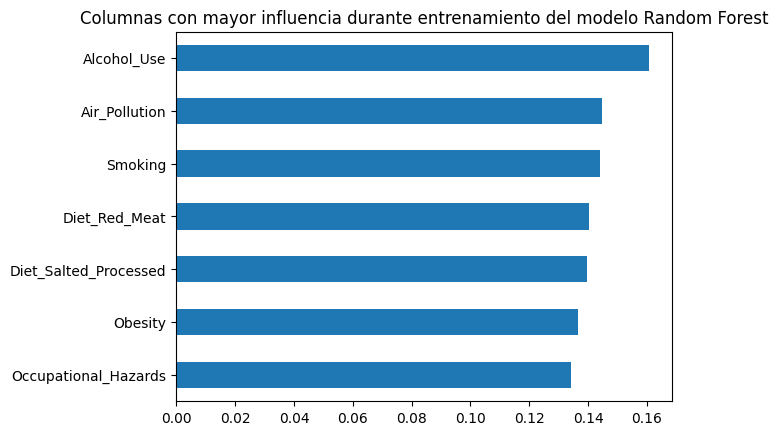

In [61]:
br = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True)
plt.title("Columnas con mayor influencia durante entrenamiento del modelo Random Forest")
br.plot.barh()